In [1]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='openpyxl')

In [2]:
data = r"C:\Users\oadar\OneDrive\Documents\Utiva\A project\Gilgal Hill EXCEL CAPSTONE PROJECT 2.xlsx"

df = pd.read_excel(data, sheet_name="Sheet1", header=1)
df.head()

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Unnamed: 8,Unnamed: 9,Admin,Dispatch,Unnamed: 12,Unnamed: 13
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,NaN,NaN,finance,Production,NaN,NaN
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,NaN,NaN,human resources,Customer Service,<1000000,5% OF SALARY
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,NaN,NaN,internal control,Quality Control,>1000000,10% OF SALARY
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,NaN,NaN,IT,R&D,NaN,NaN
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,NaN,NaN,NaN,NaN,NaN,NaN


#
# EXPLORATORY DATA ANALYSIS

#
The dataset contain irrelevant columns that are not useful to the insights the stakeholders are looking to get. hence, the irrelevant columns will be dropped.

In [5]:
# drop unwanted columns
df = df.drop(['Unnamed: 8', 'Unnamed: 9', 'Admin', 'Dispatch', 'Unnamed: 12', 'Unnamed: 13'], axis=1)
df.head()

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718


In [6]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   S/N              1000 non-null   int64  
 1   First Name       1000 non-null   object 
 2   Surname          1000 non-null   object 
 3   State of Origin  1000 non-null   object 
 4   Department       1000 non-null   object 
 5   Unit             1000 non-null   object 
 6   Bank             1000 non-null   object 
 7   Salary           1000 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 62.6+ KB


In [7]:
# Check for null values 
df.isnull().sum()

S/N                0
First Name         0
Surname            0
State of Origin    0
Department         0
Unit               0
Bank               0
Salary             0
dtype: int64

#
# CASE QUESTIONS 1

### QUESTION 1
Bonus 1 - Salary less than 1 NGN million Bonus = 5% of Salary, else Bonus = 10% of Salary

In [9]:
# Bonus 1 - Salary less than 1 NGN million Bonus = 5% of Salary, else Bonus = 10% of Salary
df['Bonus 1'] = np.where(df['Salary'] < 1000000, df['Salary'] * 0.05, df['Salary'] * 0.10)
df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718


#
### QUESTION 2
Bonus 2 - Finance dept. staff get 15% of Salary; all others get nothing

In [11]:
# Bonus 2 - Finance dept. staff get 15% of Salary; all others get nothing
df['Bonus 2'] = np.where(df['Department'] == 'Finance', df['Salary'] * 0.15, 0)
df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1,Bonus 2
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830,602030.5245
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720,0.0000
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000,0.0000
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188,0.0000
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718,0.0000


In [12]:
# confirm the values in the Bonus 2 column
print(df['Bonus 2'].unique())

[602030.5245      0.     893641.4694 555657.7134 109411.3821 341690.4753
 215988.621   52150.8711 705027.9102 340895.7297 170268.8865 108885.8076
  70393.4658 283284.5442 253675.5483 532464.5742 889756.0659 669090.6825
 289657.7253 440921.2146 756507.2766 274492.3212 602549.9775 545745.9555
 287008.6899 291480.8829 833301.1443  85217.8149 708831.4605 376906.0656
 568493.7993 857036.4735 372326.1342 681990.432  253580.5776 453843.0015
 342739.1757  77411.853  538124.8629 634467.4785 889939.3611 232762.0557
 742579.4649 292203.045  543508.8096 343668.9441 720363.1422 856121.7465
 270219.6891 366381.9828 385564.4901 450843.4665 165546.2367 363990.0504
 483392.8812 437244.8166 699694.8594 101556.9729 110978.661  200918.8872
 380119.8531 142258.6515 827072.6055 837541.9446 624143.8311 882132.1749
 341081.4735 747142.9557 332183.7858 830493.9993 523302.0879 333579.138
 806551.9383 559941.714  485414.3754 890364.8928 456814.0278 269197.2237
 156512.6517 606202.9389 602054.3109 107018.925  843

#
### QUESTION 3
Bonus 3 - Finance dept. staff, "Something For You", all others 'Nothing For You'

In [14]:
# Bonus 3 - Finance dept. staff, "Something For You", all others 'Nothing For You'
df['Bonus 3'] = np.where(df['Department'] == 'Finance', 'Something For You', 'Nothing For You')
df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1,Bonus 2,Bonus 3
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830,602030.5245,Something For You
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720,0.0000,Nothing For You
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000,0.0000,Nothing For You
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188,0.0000,Nothing For You
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718,0.0000,Nothing For You


In [15]:
print(df['Bonus 3'].unique())

['Something For You' 'Nothing For You']


#
### QUESTION 4
Bonus 4 - Finance dept. staff - 20% of Salary; IT dept. staff. 15% of Salary, Admin. Dept. Staff - 10% of Salary, all other dept. get NGN100

In [17]:
print(df['Department'].unique())

['Finance' 'Human Resources' 'Admin.' 'Internal Control' 'IT' 'R&D'
 'Dispatch' 'Production ' 'Customer Service' 'Quality Control']


In [18]:
# Bonus 4 - Finance dept. staff - 20% of Salary; IT dept. staff. 15% of Salary, Admin. Dept. Staff - 10% of Salary, all other dept. get NGN100
df['Bonus 4'] = np.where(df['Department'] == 'Finance', df['Salary'] * 0.20, 
                         np.where(df['Department'] == 'IT', df['Salary'] * 0.15,
                        np.where(df['Department'] == 'Admin.', df['Salary'] * 0.10, 100)))
df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1,Bonus 2,Bonus 3,Bonus 4
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830,602030.5245,Something For You,802707.3660
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720,0.0000,Nothing For You,100.0000
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000,0.0000,Nothing For You,105000.0000
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188,0.0000,Nothing For You,100.0000
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718,0.0000,Nothing For You,614302.9077


#
### QUESTION 5
Bonus 5 - Salary less than NGN1 million, Bonus = 15% of Salary; between NGN1 million and NGN4 million, Bonus = 10% of Salary; greater than NGN4 million, Bonus = 5% of Salary.

In [20]:
# Bonus 5 - Salary less than NGN1 million, Bonus = 15% of Salary; between NGN1 million and NGN4 million, Bonus = 10% of Salary; greater than NGN4 million, Bonus = 5% of Salary.
df['Bonus 5'] = np.where(df['Salary'] < 1000000, df['Salary'] * 0.15,
                         np.where((df['Salary'] >= 1000000) & (df['Salary'] <= 4000000), df['Salary'] * 0.10, df['Salary'] * 0.05))

df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1,Bonus 2,Bonus 3,Bonus 4,Bonus 5
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830,602030.5245,Something For You,802707.3660,200676.8415
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720,0.0000,Nothing For You,100.0000,345259.1720
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000,0.0000,Nothing For You,105000.0000,105000.0000
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188,0.0000,Nothing For You,100.0000,112473.3564
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718,0.0000,Nothing For You,614302.9077,204767.6359


#
### QUESTION 6
Bonus 6 - All Finance and Admin, dept. staff get 15% of Salary; all others get NGN100

In [22]:
# Bonus 6 - All Finance and Admin, dept. staff get 15% of Salary; all others get NGN100
df['Bonus 6'] = np.where((df['Department'] == 'Finance') | (df['Department'] == 'Admin.'), df['Salary'] * 0.15, 100)

df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1,Bonus 2,Bonus 3,Bonus 4,Bonus 5,Bonus 6
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830,602030.5245,Something For You,802707.3660,200676.8415,602030.5245
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720,0.0000,Nothing For You,100.0000,345259.1720,100.0000
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000,0.0000,Nothing For You,105000.0000,105000.0000,157500.0000
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188,0.0000,Nothing For You,100.0000,112473.3564,100.0000
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718,0.0000,Nothing For You,614302.9077,204767.6359,100.0000


#
## High earners vs Low earners (based on a defined threshold like ₦1M+)

In [24]:
# Create the High earners vs Low earners column based on a defined threshold like ₦1M+
df['Earning Category'] = np.where(df['Salary'] >= 1000000, 'High Earner', 'Low Earner')
df.head(5)

,S/N,First Name,Surname,State of Origin,Department,Unit,Bank,Salary,Bonus 1,Bonus 2,Bonus 3,Bonus 4,Bonus 5,Bonus 6,Earning Category
0,1,Olubunmi,Adeyemi,Bauchi,Finance,Account Receivables,Sub-Standard Bank,4013536.830,401353.6830,602030.5245,Something For You,802707.3660,200676.8415,602030.5245,High Earner
1,2,Albert,Ornams,Borno,Human Resources,Training & Development,Distressed Bank,3452591.720,345259.1720,0.0000,Nothing For You,100.0000,345259.1720,100.0000,High Earner
2,3,Ibi-Kunle,Ayodeji,Rivers,Admin.,MD's Office,Oasis Bank,1050000.000,105000.0000,0.0000,Nothing For You,105000.0000,105000.0000,157500.0000,High Earner
3,4,Alihu,Sarkin,Benue,Internal Control,Risk Management,Distressed Bank,749822.376,37491.1188,0.0000,Nothing For You,100.0000,112473.3564,100.0000,Low Earner
4,5,Offiong,Bassey,Rivers,IT,Desktop Support,Distressed Bank,4095352.718,409535.2718,0.0000,Nothing For You,614302.9077,204767.6359,100.0000,High Earner


In [25]:
# Check dataframe info again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S/N               1000 non-null   int64  
 1   First Name        1000 non-null   object 
 2   Surname           1000 non-null   object 
 3   State of Origin   1000 non-null   object 
 4   Department        1000 non-null   object 
 5   Unit              1000 non-null   object 
 6   Bank              1000 non-null   object 
 7   Salary            1000 non-null   float64
 8   Bonus 1           1000 non-null   float64
 9   Bonus 2           1000 non-null   float64
 10  Bonus 3           1000 non-null   object 
 11  Bonus 4           1000 non-null   float64
 12  Bonus 5           1000 non-null   float64
 13  Bonus 6           1000 non-null   float64
 14  Earning Category  1000 non-null   object 
dtypes: float64(6), int64(1), object(8)
memory usage: 117.3+ KB


In [26]:
df.describe()

,S/N,Salary,Bonus 1,Bonus 2,Bonus 4,Bonus 5,Bonus 6
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,427.671000,3.119392e+06,308244.983021,82643.196111,1.832599e+05,228481.516831,147671.108287
std,305.681419,1.646774e+06,170376.107230,207826.200193,3.000833e+05,80537.596579,259832.313548
min,1.000000,2.607880e+05,13039.400000,0.000000,1.000000e+02,39118.200000,100.000000
25%,136.750000,1.742691e+06,174269.090650,0.000000,1.000000e+02,174269.090650,100.000000
50%,394.500000,3.031456e+06,303145.642300,0.000000,1.000000e+02,237638.177600,100.000000
75%,692.250000,4.593012e+06,459301.172050,0.000000,3.084252e+05,282096.349125,205824.132600
max,999.000000,6.001580e+06,600157.965600,893641.469400,1.191522e+06,399189.237200,895382.948700


#
# CASE QUESTIONS 2
### HEADCOUNT ANALYSIS

#### Total Number of Employee (Total Headcounts)

In [28]:
# Total Number of Employees, counting the total number of entries in the dataset. Each entry represents one employee.
df.shape[0]

1000

#
### Headcounts by Department


In [30]:
# Total Number of Employees by Department
dept_counts = df['Department'].value_counts()

# Convert to DataFrame and reset index
dept_counts_df = dept_counts.reset_index()

# Adjust column name for clarity
dept_counts_df.columns = ['Department', 'Counts']

# Display as a table
display(dept_counts_df)

,Department,Counts
0,Human Resources,220
1,Finance,172
2,Admin.,140
3,IT,69
4,Customer Service,69
5,Internal Control,66
6,R&D,66
7,Dispatch,66
8,Production,66
9,Quality Control,66


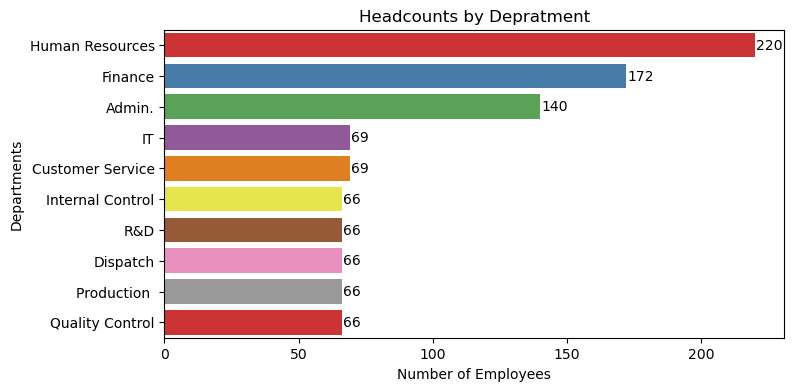

In [31]:
# Creating a bar chart to analyse employees by department
department_counts = df['Department'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.grid(False)
department_plot = sns.barplot(
    x=department_counts.values,
    y=department_counts.index,
    hue=department_counts.index,
    palette='Set1',
    legend=False)
for i, v in enumerate(department_counts.values):
    department_plot.annotate(str(v), xy=(v + 0.4, i), ha='left', va='center')

# Adding labels and title
plt.xlabel('Number of Employees')
plt.ylabel('Departments')
plt.title('Headcounts by Depratment')
#plt.savefig('Headcounts by Department.png')
plt.show()

#
### Headcounts by Unit

In [33]:
unit_count = df['Unit'].value_counts()

# Convert to DataFrame and reset index
unit_count_df = unit_count.reset_index()

# Adjust column name for clarity
unit_count_df.columns = ['Units', 'Counts']

# Display as a table
display(unit_count_df)

,Units,Counts
0,Training & Development,74
1,Benefits Admin.,73
2,Payroll,73
3,Account Receivables,58
4,Budgeting,57
5,Account Payables,57
6,Expenditure,47
7,MD's Office,47
8,Supplies,46
9,Call Center,45


#
### Plot of Headcounts by Unit (Top 5)

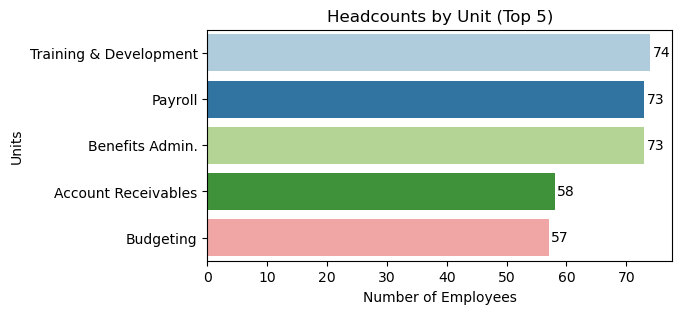

In [35]:
# Creating a bar chart to analyse employees by Unit (Top 5)

unit_counts = df['Unit'].value_counts().sort_values(ascending=False).head(5)
plt.figure(figsize=(6, 3))
plt.grid(False)
unit_plot = sns.barplot(x=unit_counts.values,
                        y=unit_counts.index,
                        hue=unit_counts.index,
                        palette='Paired',
                        legend=False)
for i, v in enumerate(unit_counts.values):
    unit_plot.annotate(str(v), xy=(v + 0.4, i), ha='left', va='center', fontsize=10)

# Add labels and title
plt.xlabel('Number of Employees')
plt.ylabel('Units')
plt.title('Headcounts by Unit (Top 5)')
plt.show()

#
### Plot of Headcounts by Unit (Bottom 5)

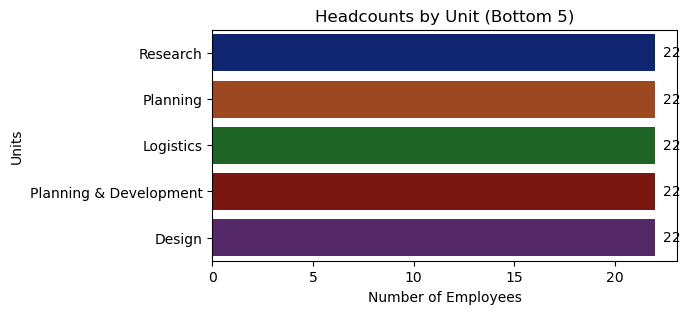

In [37]:
# Creating a bar chart to analyse employees by Unit (Bottom 5)

unit_counts = df['Unit'].value_counts().sort_values(ascending=False).tail(5)
plt.figure(figsize=(6, 3))
plt.grid(False)
unit_plot = sns.barplot(x=unit_counts.values,
                        y=unit_counts.index,
                        hue=unit_counts.index,
                        palette='dark',
                        legend=False)
for i, v in enumerate(unit_counts.values):
    unit_plot.annotate(str(v), xy=(v + 0.4, i), ha='left', va='center', fontsize=10)

# Add labels and title
plt.xlabel('Number of Employees')
plt.ylabel('Units')
plt.title('Headcounts by Unit (Bottom 5)')
plt.show()

#
### Headcounts by State of Origin

In [39]:
soo_counts = df['State of Origin'].value_counts()

# Convert to DataFrame and reset index
soo_counts_df = soo_counts.reset_index()

# Rename column for clarity
soo_counts_df.columns = ['State of Origin', 'Counts']

# Disply Dataframe
display(soo_counts_df)

,State of Origin,Counts
0,Bauchi,86
1,Ekiti,57
2,Cross-River,53
3,Anambra,44
4,Rivers,44
5,Katsina,43
6,Lagos,42
7,Kwara,42
8,Taraba,41
9,Delta,39


#
## Visualise counts of Employees By State of Origin (Top 10)

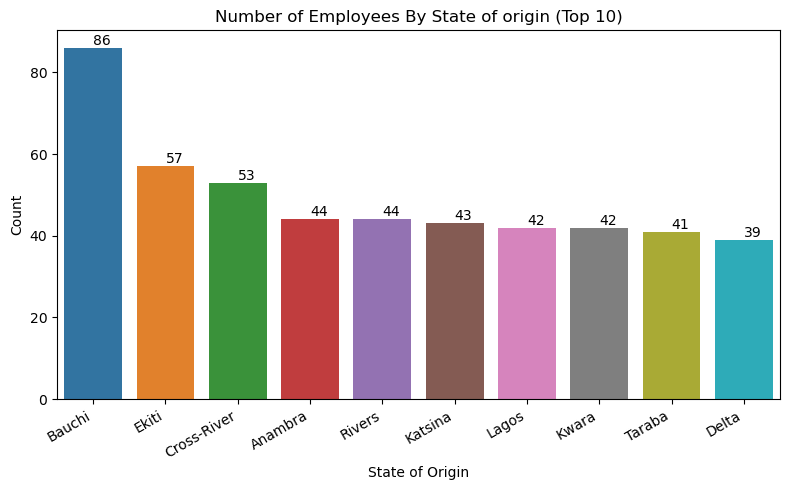

In [41]:
soo_counts_fil = df['State of Origin'].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=soo_counts_fil.index, y=soo_counts_fil.values, hue=soo_counts_fil.index, palette='tab10', legend=False)
plt.title('Number of Employees By State of origin (Top 10)', fontsize=12)
plt.xlabel('State of Origin')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

# Add labels on bars
for i, v in enumerate(soo_counts_fil.values):
    plt.text(i, v, f'{v:,.0f}', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()

#
## Visualise counts of Employees By State of Origin (Bottom 10)

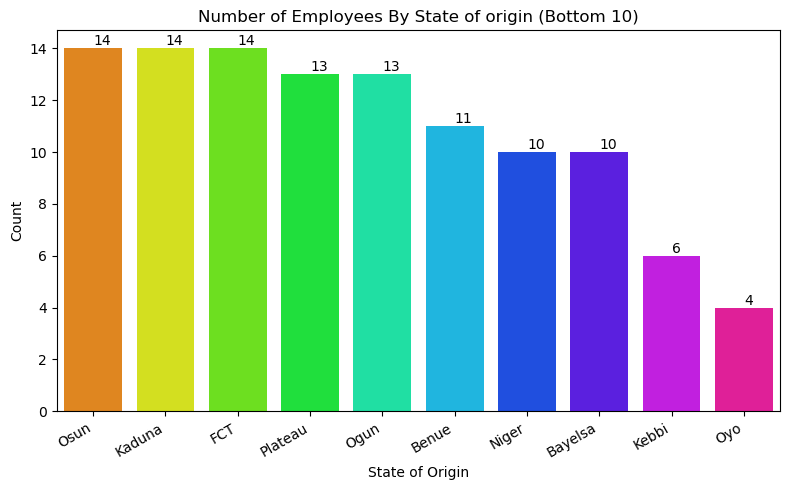

In [43]:
soo_counts_bot = df['State of Origin'].value_counts().tail(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=soo_counts_bot.index, y=soo_counts_bot.values, hue=soo_counts_bot.index, palette='hsv', legend=False)
plt.title('Number of Employees By State of origin (Bottom 10)', fontsize=12)
plt.xlabel('State of Origin')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

# Add labels on bars
for i, v in enumerate(soo_counts_bot.values):
    plt.text(i, v, f'{v:,.0f}', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()

#
# SALARY ANALYSIS

### Total Salary

In [45]:
# Calculate the total Salary
total_salary = df['Salary'].sum()
print(f'Total Salary: ₦{total_salary:,.0f}')

Total Salary: ₦3,119,391,524


#
### Average Salary

In [47]:
# Calculate Average Salary
average_salary = df['Salary'].mean()
print(f'Average Salary: ₦{average_salary:,.2f}')

Average Salary: ₦3,119,391.52


#
### Salary By Department (Sum)

In [49]:
department_salary = df.groupby('Department')['Salary'].sum().sort_values(ascending=False)

In [50]:
# Convert to DataFrame and reset index
department_salary_df = department_salary.reset_index()

# Rename columns for clarity
department_salary_df.columns = ['Department', 'Total Salary (₦)']

# Format salary with commas
department_salary_df['Total Salary (₦)'] = department_salary_df['Total Salary (₦)'].apply(lambda x: f'₦{x:,.0f}')

# Display as a table
display(department_salary_df)

,Department,Total Salary (₦)
0,Human Resources,"₦703,109,084"
1,Finance,"₦550,954,641"
2,Admin.,"₦433,060,748"
3,Customer Service,"₦225,264,447"
4,Dispatch,"₦225,087,038"
5,Quality Control,"₦216,528,050"
6,Production,"₦198,533,030"
7,IT,"₦198,006,828"
8,R&D,"₦190,228,835"
9,Internal Control,"₦178,618,822"


#
### Visualise Salary By Department (Sum)

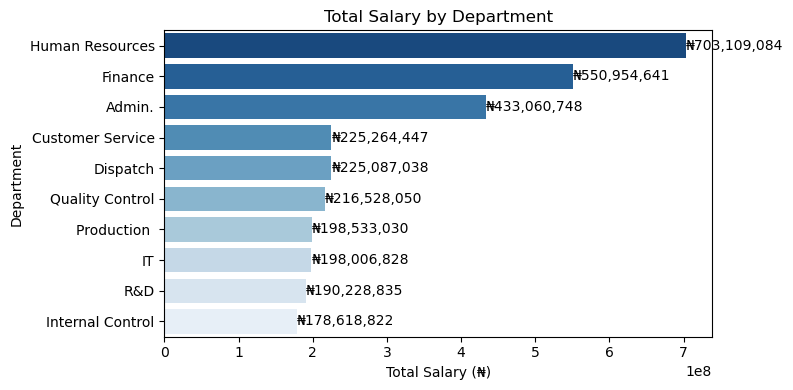

In [52]:
plt.figure(figsize=(8, 4))
sns.barplot(x=department_salary.values, y=department_salary.index, hue=department_salary.index, palette='Blues_r')
plt.title('Total Salary by Department')
plt.xlabel('Total Salary (₦)')
plt.ylabel('Department')

# Add labels on bars
for i, v in enumerate(department_salary.values):
    plt.text(v, i, f"₦{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

#
### Salary By Department (Average)

In [54]:
dept_salary_avg = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)

# Convert to DataFrame and reset index
dept_salary_df = dept_salary_avg.reset_index()

# Rename columns for clarity
dept_salary_df.columns = ['Department', 'Average Salary (₦)']

# Format salary with commas
dept_salary_df['Average Salary (₦)'] = dept_salary_df['Average Salary (₦)'].apply(lambda x: f'₦{x:,.0f}')

# Display as a table
display(dept_salary_df)

,Department,Average Salary (₦)
0,Dispatch,"₦3,410,410"
1,Quality Control,"₦3,280,728"
2,Customer Service,"₦3,264,702"
3,Finance,"₦3,203,225"
4,Human Resources,"₦3,195,950"
5,Admin.,"₦3,093,291"
6,Production,"₦3,008,076"
7,R&D,"₦2,882,255"
8,IT,"₦2,869,664"
9,Internal Control,"₦2,706,346"


#
### Visualise Salary By Department (Average)

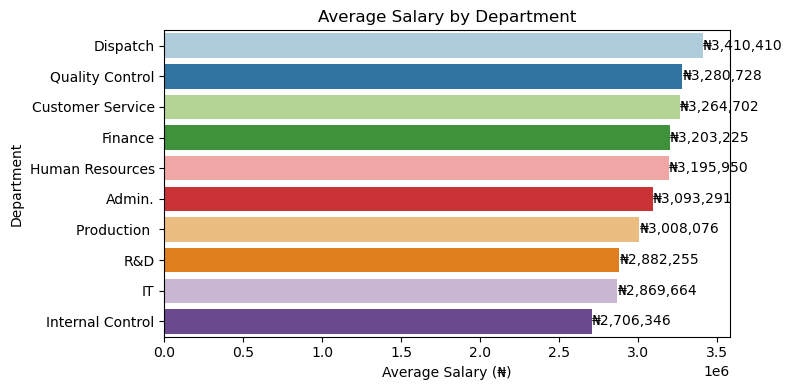

In [56]:
plt.figure(figsize=(8, 4))
sns.barplot(x=dept_salary_avg.values, y=dept_salary_avg.index, hue=dept_salary_avg.index, palette='Paired')
plt.title('Average Salary by Department')
plt.xlabel('Average Salary (₦)')
plt.ylabel('Department')

# Add labels on bars
for i, v in enumerate(dept_salary_avg.values):
    plt.text(v, i, f"₦{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

#
### Salary By Unit (Sum)

In [58]:
unit_salary = df.groupby('Unit')['Salary'].sum().sort_values(ascending=False)

# Convert to DataFrame and reset index
unit_salary_df = unit_salary.reset_index()

# Rename columns for clarity
unit_salary_df.columns = ['Unit', 'Total Salary (₦)']

# Format salary with commas
unit_salary_df['Total Salary (₦)'] = unit_salary_df['Total Salary (₦)'].apply(lambda x: f'₦{x:,.0f}')

# Display as a table
display(unit_salary_df)

,Unit,Total Salary (₦)
0,Benefits Admin.,"₦246,081,873"
1,Training & Development,"₦238,647,642"
2,Payroll,"₦218,379,569"
3,Budgeting,"₦189,235,636"
4,Account Payables,"₦181,348,497"
5,Account Receivables,"₦180,370,507"
6,Call Center,"₦167,537,699"
7,Supplies,"₦150,125,971"
8,Maintenance,"₦147,675,198"
9,MD's Office,"₦143,226,464"


#
### Visualise Salary By Unit (Sum)

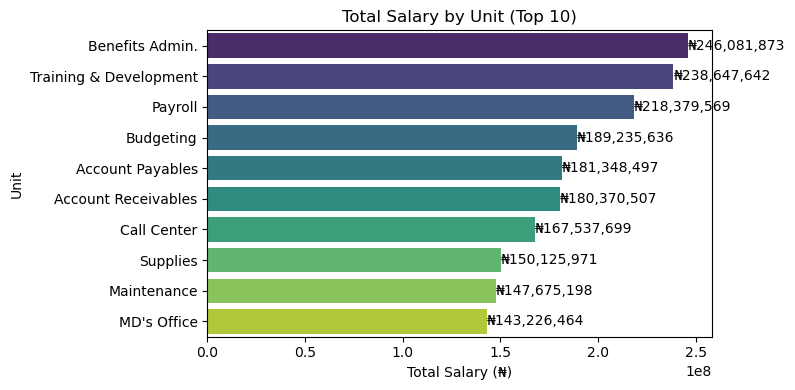

In [60]:
unitt_salary = df.groupby('Unit')['Salary'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=unitt_salary.values, y=unitt_salary.index, hue=unitt_salary.index, palette='viridis')
plt.title('Total Salary by Unit (Top 10)')
plt.xlabel('Total Salary (₦)')
plt.ylabel('Unit')

# Add labels on bars
for i, v in enumerate(unitt_salary.values):
    plt.text(v, i, f"₦{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

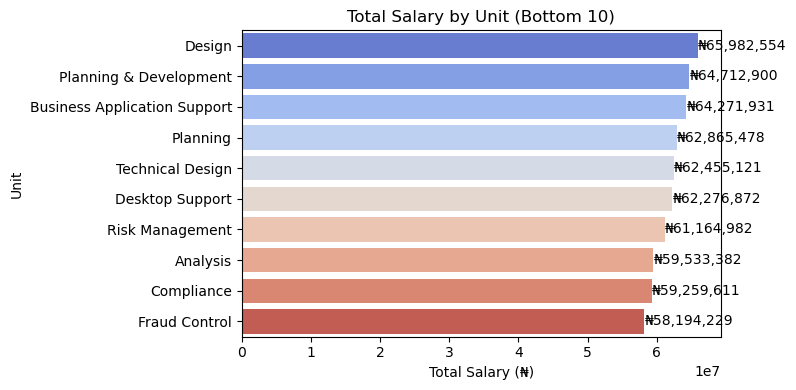

In [61]:
uni_salary = df.groupby('Unit')['Salary'].sum().sort_values(ascending=False).tail(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=uni_salary.values, y=uni_salary.index, hue=uni_salary.index, palette='coolwarm')
plt.title('Total Salary by Unit (Bottom 10)')
plt.xlabel('Total Salary (₦)')
plt.ylabel('Unit')

# Add labels on bars
for i, v in enumerate(uni_salary.values):
    plt.text(v, i, f"₦{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

#
### Salary By Unit (Average)

In [63]:
unit_salary_avg = df.groupby('Unit')['Salary'].mean().sort_values(ascending=False)

# Convert to DataFrame and reset index
unit_salary_avg_df = unit_salary_avg.reset_index()

# Rename columns for clarity
unit_salary_avg_df.columns = ['Unit', 'Average Salary (₦)']

# Format salary with commas
unit_salary_avg_df['Average Salary (₦)'] = unit_salary_avg_df['Average Salary (₦)'].apply(lambda x: f'₦{x:,.0f}')

# Display as a table
display(unit_salary_avg_df)

,Unit,Average Salary (₦)
0,Call Center,"₦3,723,060"
1,Logistics,"₦3,419,229"
2,Benefits Admin.,"₦3,370,985"
3,Maintenance,"₦3,356,254"
4,Budgeting,"₦3,319,923"
5,Training,"₦3,263,891"
6,Supplies,"₦3,263,608"
7,Training & Development,"₦3,224,968"
8,Research,"₦3,193,622"
9,Account Payables,"₦3,181,553"


#
### Visualise Salary By Unit (Average)

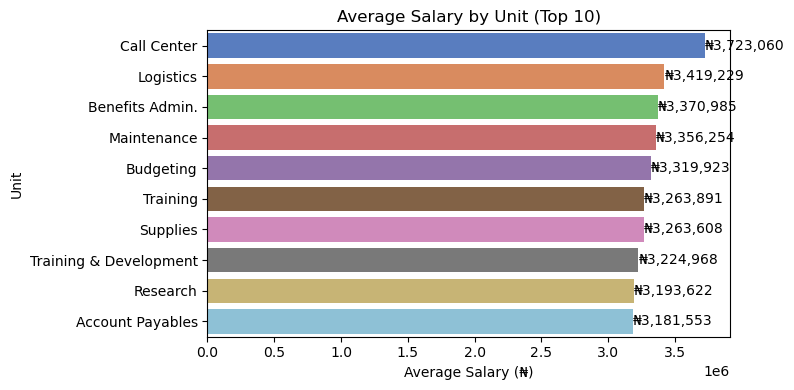

In [65]:
# Top 10 Average Salary By unit
unitt_salary_avg = df.groupby('Unit')['Salary'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=unitt_salary_avg.values, y=unitt_salary_avg.index, hue=unitt_salary_avg.index, palette='muted')
plt.title('Average Salary by Unit (Top 10)')
plt.xlabel('Average Salary (₦)')
plt.ylabel('Unit')

# Add labels on bars
for i, v in enumerate(unitt_salary_avg.values):
    plt.text(v, i, f"₦{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

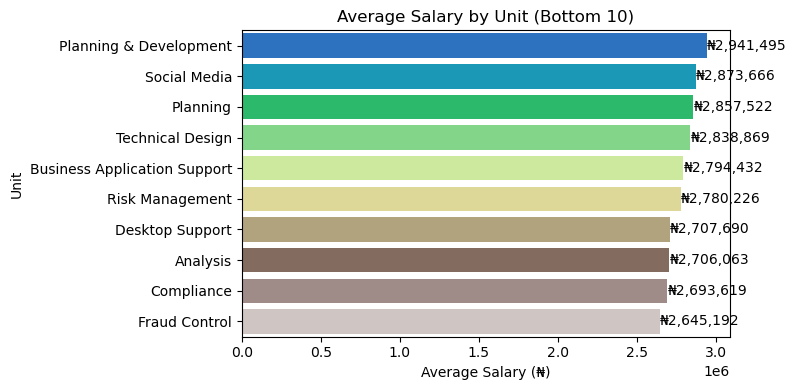

In [66]:
# Bottom 10 Salary By Unit
uni_salary_avg = df.groupby('Unit')['Salary'].mean().sort_values(ascending=False).tail(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=uni_salary_avg.values, y=uni_salary_avg.index, hue=uni_salary_avg.index, palette='terrain')
plt.title('Average Salary by Unit (Bottom 10)')
plt.xlabel('Average Salary (₦)')
plt.ylabel('Unit')

# Add labels on bars
for i, v in enumerate(uni_salary_avg.values):
    plt.text(v, i, f"₦{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

#
# Salary Distribution By State of Origin

In [68]:
state_of_origin = df.groupby('State of Origin')['Salary'].sum().sort_values(ascending=False)

# Convert to DataFrame and reset index
state_of_origin_df = state_of_origin.reset_index()

# Rename columns for clarity
state_of_origin_df.columns = ['State of Origin', 'Total Salary (₦)']

# Format salary with commas
state_of_origin_df['Total Salary (₦)'] = state_of_origin_df['Total Salary (₦)'].apply(lambda x: f'₦{x:,.0f}')

# Display as a table
display(state_of_origin_df)

,State of Origin,Total Salary (₦)
0,Bauchi,"₦271,034,863"
1,Ekiti,"₦179,695,877"
2,Cross-River,"₦165,193,743"
3,Taraba,"₦145,543,703"
4,Kwara,"₦137,600,992"
5,Anambra,"₦133,789,907"
6,Delta,"₦133,415,187"
7,Katsina,"₦129,160,148"
8,Rivers,"₦125,258,887"
9,Lagos,"₦122,918,433"


#
# Visualise Salary Distribution by State of Origin (Top 10)

### Top 10

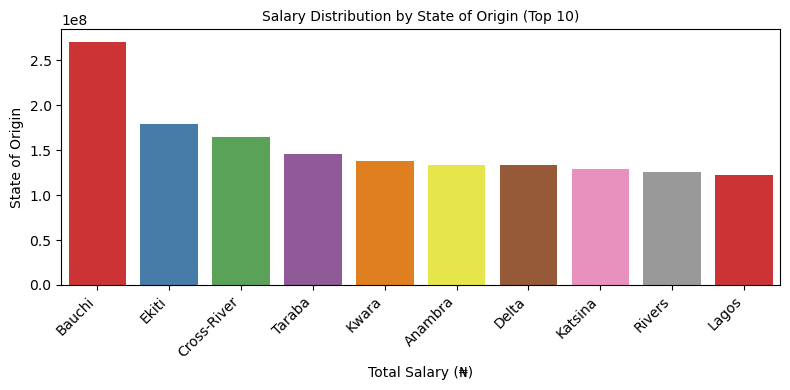

In [70]:
# Top 10 Salary By Unit
state_of_origin_vis = df.groupby('State of Origin')['Salary'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=state_of_origin_vis.index, y=state_of_origin_vis.values, hue=state_of_origin_vis.index, palette='Set1', legend=False)
plt.title('Salary Distribution by State of Origin (Top 10)', fontsize=10)
plt.xlabel('Total Salary (₦)')
plt.ylabel('State of Origin')
plt.xticks(rotation=45, ha='right')

# Add labels on bars
#for i, v in enumerate(state_of_origin_vis.values):
 #   plt.text(i, v, f"₦{v:,.0f}", va='bottom', rotation=20, fontsize=10)

plt.tight_layout()
plt.show()

#
# Visualise Salary Distribution by State of Origin (Bottom 10)
### Bottom 10

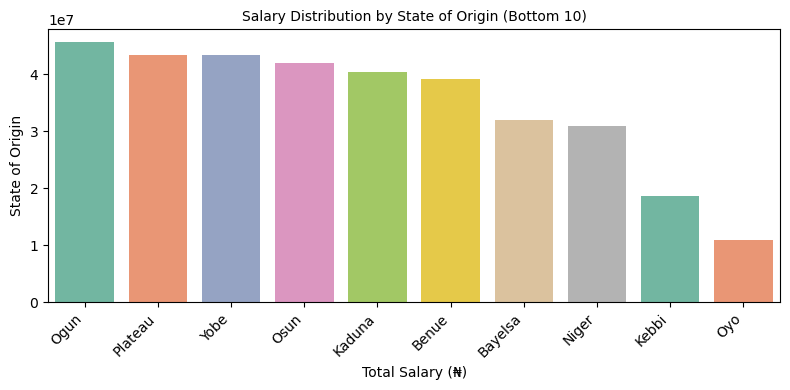

In [72]:
# Top 10 Salary By Unit
soo_vis = df.groupby('State of Origin')['Salary'].sum().sort_values(ascending=False).tail(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=soo_vis.index, y=soo_vis.values, hue=soo_vis.index, palette='Set2', legend=False)
plt.title('Salary Distribution by State of Origin (Bottom 10)', fontsize=10)
plt.xlabel('Total Salary (₦)')
plt.ylabel('State of Origin')
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()

#
#
# High earners vs Low earners

In [74]:
earning_category_counts = df['Earning Category'].value_counts()

# Convert to DataFrame and reset index
earning_category_counts_df = earning_category_counts.reset_index()

# Rename columns for clarity
earning_category_counts_df.columns = ['Earning Category', 'Counts']

# Display as a table
display(earning_category_counts_df)

,Earning Category,Counts
0,High Earner,884
1,Low Earner,116


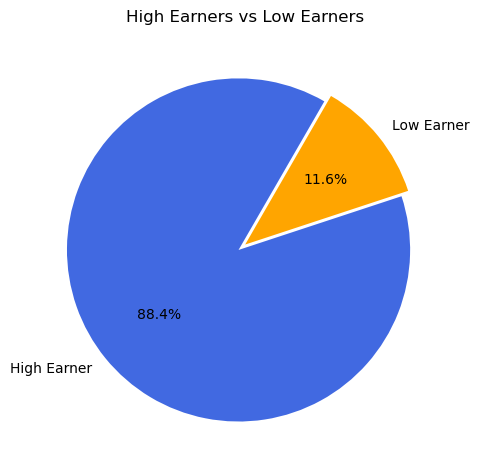

In [75]:
# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(
    earning_category_counts.values,
    labels=earning_category_counts.index,
    autopct='%1.1f%%',  
    startangle=60,  
    colors=['royalblue', 'orange'],
    explode=(0.05, 0)   
)
plt.title('High Earners vs Low Earners')
plt.tight_layout()
plt.show()

#
#
# Most Used Bank

In [77]:
# count the most used Bank
mub = df['Bank'].value_counts()

# Convert to Dataframe and reset index
mub_df = mub.reset_index()

# Rename columns for clarity
mub_df.columns = ['Bank', 'Counts']

# Display as a table
display(mub_df)

,Bank,Counts
0,Sub-Standard Bank,268
1,Distressed Bank,193
2,Atlantic Bank,193
3,Last Bank Of Nigeria,154
4,Oasis Bank,115
5,Money Doublers' Bank,77


#
## Visualise Most Used Bank

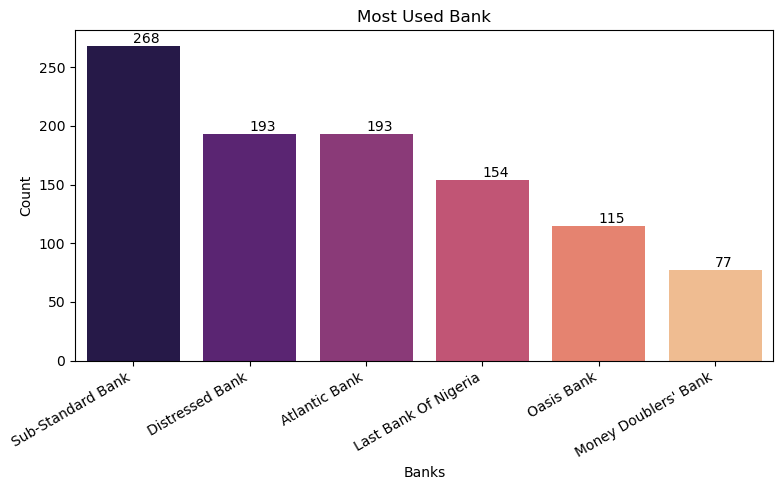

In [79]:
plt.figure(figsize=(8, 5))
sns.barplot(x=mub.index, y=mub.values, hue=mub.index, palette='magma', legend=False)
plt.title('Most Used Bank', fontsize=12)
plt.xlabel('Banks')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

# Add labels on bars
for i, v in enumerate(mub.values):
    plt.text(i, v, f'{v:,.0f}', va='bottom', fontsize=10)


plt.tight_layout()
plt.show()

#
#
# Salary Distribution By Bank

In [81]:
mub_sal = df.groupby('Bank')['Salary'].sum().sort_values(ascending=False)

# Convert to DataFrame and reset index
mub_sal_df = mub_sal.reset_index()

# Adjust column name for clarity
mub_sal_df.columns = ['Bank', 'Total Salary (₦)']

# Format salary with commas
mub_sal_df['Total Salary (₦)'] = mub_sal_df['Total Salary (₦)'].apply(lambda x: f'₦{x:,.0f}')

# Display as a table
display(mub_sal_df)

,Bank,Total Salary (₦)
0,Sub-Standard Bank,"₦863,608,772"
1,Distressed Bank,"₦610,217,001"
2,Atlantic Bank,"₦551,890,946"
3,Last Bank Of Nigeria,"₦484,172,341"
4,Oasis Bank,"₦357,489,338"
5,Money Doublers' Bank,"₦252,013,126"


#
## Visualise Salary Distribution By Bank

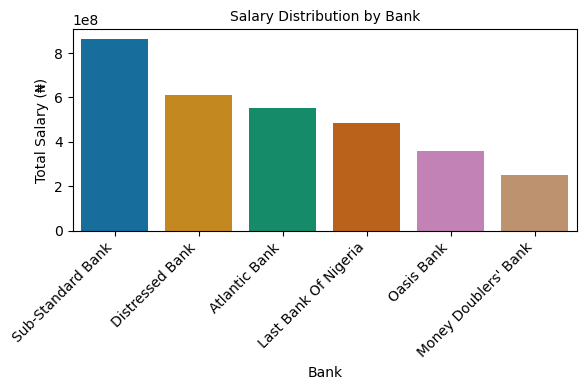

In [83]:
# Salary Distribution By Bank
mub_sal_vis = df.groupby('Bank')['Salary'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=mub_sal_vis.index, y=mub_sal_vis.values, hue=mub_sal_vis.index, palette='colorblind', legend=False)
plt.title('Salary Distribution by Bank', fontsize=10)
plt.xlabel('Bank')
plt.ylabel('Total Salary (₦)')
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()